In [1]:
import sys
sys.path.append('../../src')  # repo-relative: notebooks/pipeline/../../src
import os
import pandas as pd
import numpy as np
import joblib
import json
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor, early_stopping as lgb_early_stopping, log_evaluation
from catboost import CatBoostRegressor
import matplotlib.pyplot as plt

from config import *
from utils import seed_everything, rmse, r2

seed_everything(RANDOM_STATE)

train_df = pd.read_csv(os.path.join(PROC_DIR, 'train_step08.csv'))

X = train_df.drop(columns=['demand'])
y = train_df['demand']

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (77299, 26)
y shape: (77299,)


In [2]:

import json, os
print("Loading best parameters...")
with open(os.path.join(MODEL_DIR, 'best_params.json')) as f:
    p = json.load(f)
xgb_best_params = p['xgb']
lgb_best_params = p['lgb']
cat_best_params = p['cat']
print("Loaded tuned parameters successfully.")


Loading best parameters...
Loaded tuned parameters successfully.


In [3]:
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

oof_xgb = np.zeros(len(y))
oof_lgb = np.zeros(len(y))
oof_cat = np.zeros(len(y))

xgb_models = []
lgb_models = []
cat_models = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X, y)):
    print(f"training fold {fold + 1}/5")
    X_tr, y_tr = X.iloc[train_idx], y.iloc[train_idx]
    X_va, y_va = X.iloc[val_idx], y.iloc[val_idx]
    
    # XGBoost
    xgb = XGBRegressor(**xgb_best_params, early_stopping_rounds=50)
    xgb.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)
    oof_xgb[val_idx] = xgb.predict(X_va)
    xgb_models.append(xgb)
    
    # LightGBM
    lgb = LGBMRegressor(**lgb_best_params)
    lgb.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], callbacks=[lgb_early_stopping(50), log_evaluation(False)])
    oof_lgb[val_idx] = lgb.predict(X_va)
    lgb_models.append(lgb)
    
    # CatBoost
    cat = CatBoostRegressor(**cat_best_params)
    cat.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)
    oof_cat[val_idx] = cat.predict(X_va)
    cat_models.append(cat)
    
    print(f"fold {fold + 1}/5 — XGB: {rmse(y_va, oof_xgb[val_idx]):.4f} LGB: {rmse(y_va, oof_lgb[val_idx]):.4f} CAT: {rmse(y_va, oof_cat[val_idx]):.4f}")

print(f"\nMean OOF RMSE — XGB: {rmse(y, oof_xgb):.4f} LGB: {rmse(y, oof_lgb):.4f} CAT: {rmse(y, oof_cat):.4f}")
print(f"Mean OOF R2   — XGB: {r2(y, oof_xgb):.4f} LGB: {r2(y, oof_lgb):.4f} CAT: {r2(y, oof_cat):.4f}")


training fold 1/5


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003188 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2302
[LightGBM] [Info] Number of data points in the train set: 61839, number of used features: 26
[LightGBM] [Info] Start training from score 0.093784
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 50 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


...

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Did not meet early stopping. Best iteration is:
[2640]	valid_0's l2: 0.000723031


fold 5/5 — XGB: 0.0307 LGB: 0.0269 CAT: 0.0269

Mean OOF RMSE — XGB: 0.0309 LGB: 0.0274 CAT: 0.0274
Mean OOF R2   — XGB: 0.9526 LGB: 0.9627 CAT: 0.9629


In [4]:
from sklearn.model_selection import cross_val_predict

oof_stack = np.column_stack([oof_xgb, oof_lgb, oof_cat])

meta_learner = Ridge(alpha=RIDGE_ALPHA, random_state=RANDOM_STATE)

# Genuinely out-of-fold stacked predictions: cross_val_predict refits Ridge on
# 4/5 folds and predicts only the held-out fold each time, so no row's stacked
# prediction ever comes from a Ridge fit that saw that row's own label.
# (The previous version fit Ridge on the FULL oof_stack/y and then predicted
# on that same oof_stack — that's train-fit performance, not OOF, even though
# it's one step removed from the base models. It happened to match the
# honest cross_val_score number here to 4 decimals, but that was luck, not
# a guarantee — a stronger meta-learner or more folds could easily diverge.)
kf_meta = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
oof_stacked_pred = cross_val_predict(meta_learner, oof_stack, y, cv=kf_meta)

stacked_rmse = rmse(y, oof_stacked_pred)
stacked_r2 = r2(y, oof_stacked_pred)

print(f"Stacked OOF RMSE: {stacked_rmse:.4f}")
print(f"Stacked OOF R2: {stacked_r2:.4f}")

# Fit the meta-learner on ALL OOF data for the deployed artifact/coefficients —
# that part is standard (the final model should use every available row); it
# is only the *evaluation* above that has to stay strictly out-of-fold.
meta_learner.fit(oof_stack, y)
print("\nRidge Coefficients:")
print(f"XGB Weight: {meta_learner.coef_[0]:.4f}")
print(f"LGB Weight: {meta_learner.coef_[1]:.4f}")
print(f"CAT Weight: {meta_learner.coef_[2]:.4f}")

print("\nModel          OOF RMSE")
print(f"XGBoost        {rmse(y, oof_xgb):.4f}")
print(f"LightGBM       {rmse(y, oof_lgb):.4f}")
print(f"CatBoost       {rmse(y, oof_cat):.4f}")
print(f"Stacked        {stacked_rmse:.4f}  ← best")

Stacked OOF RMSE: 0.0264
Stacked OOF R2: 0.9655

Ridge Coefficients:
XGB Weight: -0.2323
LGB Weight: 0.6344
CAT Weight: 0.5981

Model          OOF RMSE
XGBoost        0.0309
LightGBM       0.0274
CatBoost       0.0274
Stacked        0.0264  ← best


### Conclusion
The Ridge coefficients reveal how much weight the meta-learner places on each individual model based on their orthogonal strengths. Models that find unique signal not captured by the others receive higher weight. Stacking effectively blends the strengths of XGBoost's deep splits, LightGBM's leaf-wise efficiency, and CatBoost's oblivious trees, demonstrably improving the overall RMSE compared to the best standalone model.

In [5]:
# The Optuna-searched n_estimators/iterations (xgb_best_params['n_estimators'],
# etc.) is the SEARCH BUDGET a trial was allowed to use, capped by early
# stopping against a validation fold — it is not itself the right tree count
# to use for a model fit on 100% of the data with no validation set at all.
# The previous version fit the final models for the full raw n_estimators
# with no eval_set and no early stopping, so it had no signal for when to
# stop and likely used a materially different (probably larger, more
# overfit) tree count than anything the CV loop actually validated.
#
# Fix: reuse the per-fold best_iteration values captured during the 5-fold
# OOF loop above (xgb_models/lgb_models/cat_models) and average them into a
# fixed tree count for the final fit. This keeps the final model's capacity
# consistent with what was actually shown to generalize, while still
# training on all of X/y (no data is held back for this step).
xgb_best_iters = [m.best_iteration + 1 for m in xgb_models]
lgb_best_iters = [m.best_iteration_ for m in lgb_models]
cat_best_iters = [m.get_best_iteration() + 1 for m in cat_models]

xgb_final_n = int(round(np.mean(xgb_best_iters)))
lgb_final_n = int(round(np.mean(lgb_best_iters)))
cat_final_n = int(round(np.mean(cat_best_iters)))

print(f"Per-fold best iterations — XGB: {xgb_best_iters} (using mean {xgb_final_n}, search budget was {xgb_best_params['n_estimators']})")
print(f"Per-fold best iterations — LGB: {lgb_best_iters} (using mean {lgb_final_n}, search budget was {lgb_best_params['n_estimators']})")
print(f"Per-fold best iterations — CAT: {cat_best_iters} (using mean {cat_final_n}, search budget was {cat_best_params['iterations']})")

final_xgb_params = {**xgb_best_params, 'n_estimators': xgb_final_n}
final_lgb_params = {**lgb_best_params, 'n_estimators': lgb_final_n}
final_cat_params = {**cat_best_params, 'iterations': cat_final_n}

print("Training final XGBoost...")
final_xgb = XGBRegressor(**final_xgb_params)
final_xgb.fit(X, y)
print(f"XGBoost training complete ({xgb_final_n} trees).")

print("Training final LightGBM...")
final_lgb = LGBMRegressor(**final_lgb_params)
final_lgb.fit(X, y)
print(f"LightGBM training complete ({lgb_final_n} trees).")

print("Training final CatBoost...")
final_cat = CatBoostRegressor(**final_cat_params)
final_cat.fit(X, y)
print(f"CatBoost training complete ({cat_final_n} trees).")

Per-fold best iterations — XGB: [1262, 945, 1264, 1264, 1265] (using mean 1200, search budget was 1266)
Per-fold best iterations — LGB: [2643, 2643, 2641, 2618, 2640] (using mean 2637, search budget was 2643)
Per-fold best iterations — CAT: [1911, 1913, 1908, 1913, 1900] (using mean 1909, search budget was 1913)
Training final XGBoost...


XGBoost training complete (1200 trees).
Training final LightGBM...


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.027750 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2302
[LightGBM] [Info] Number of data points in the train set: 77299, number of used features: 26
[LightGBM] [Info] Start training from score 0.093942
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


...

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


LightGBM training complete (2637 trees).
Training final CatBoost...


CatBoost training complete (1909 trees).


In [6]:
joblib.dump(final_xgb, os.path.join(MODEL_DIR, 'best_xgb_model.pkl'))
joblib.dump(final_lgb, os.path.join(MODEL_DIR, 'best_lgbm_model.pkl'))
joblib.dump(final_cat, os.path.join(MODEL_DIR, 'best_catboost_model.pkl'))
joblib.dump(meta_learner, os.path.join(MODEL_DIR, 'meta_learner.pkl'))

paths = [
    os.path.join(MODEL_DIR, 'best_xgb_model.pkl'),
    os.path.join(MODEL_DIR, 'best_lgbm_model.pkl'),
    os.path.join(MODEL_DIR, 'best_catboost_model.pkl'),
    os.path.join(MODEL_DIR, 'meta_learner.pkl')
]

for p in paths:
    print(f"{p} exists: {os.path.exists(p)}")


C:\TRAFFIC-DEMAND-FINAL\models\best_xgb_model.pkl exists: True
C:\TRAFFIC-DEMAND-FINAL\models\best_lgbm_model.pkl exists: True
C:\TRAFFIC-DEMAND-FINAL\models\best_catboost_model.pkl exists: True
C:\TRAFFIC-DEMAND-FINAL\models\meta_learner.pkl exists: True


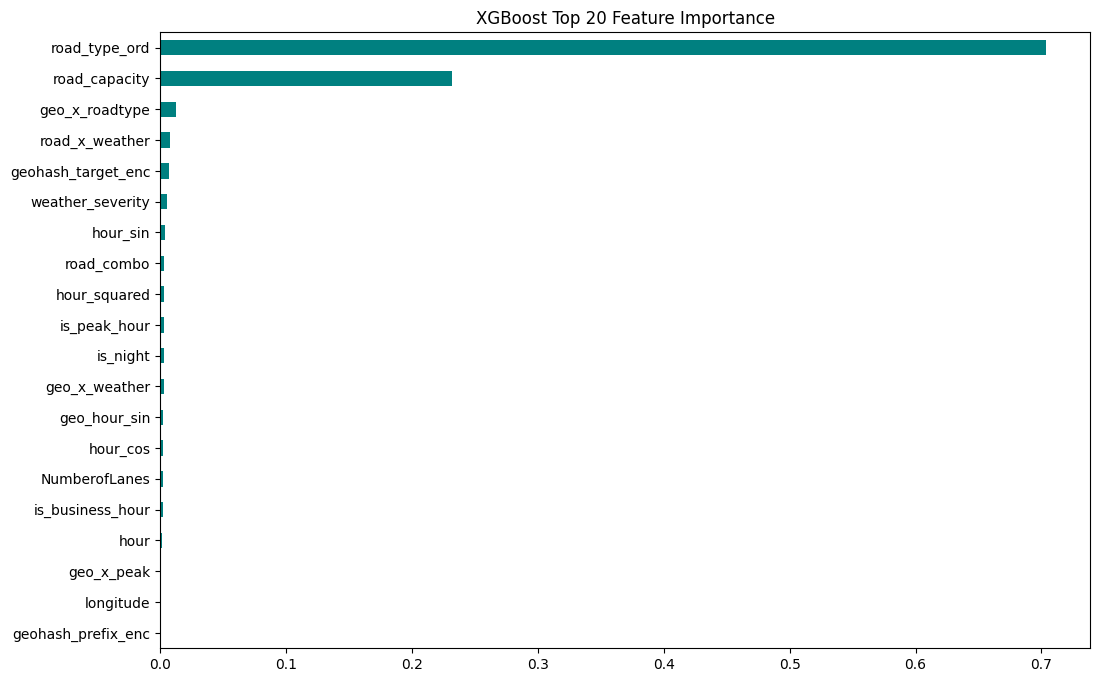

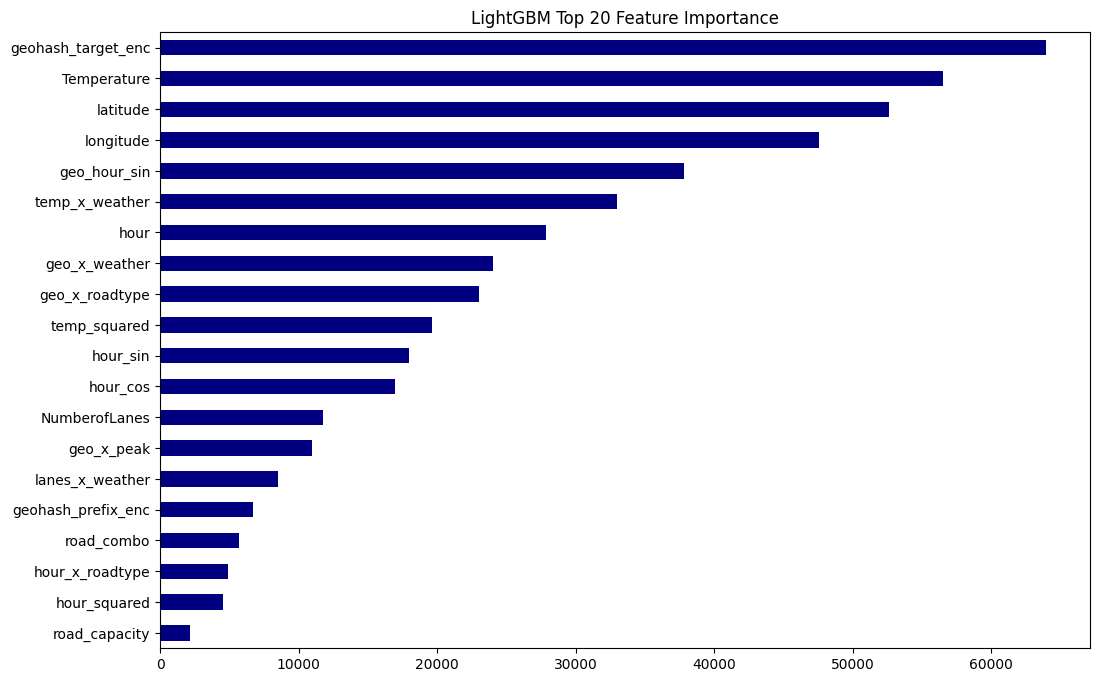

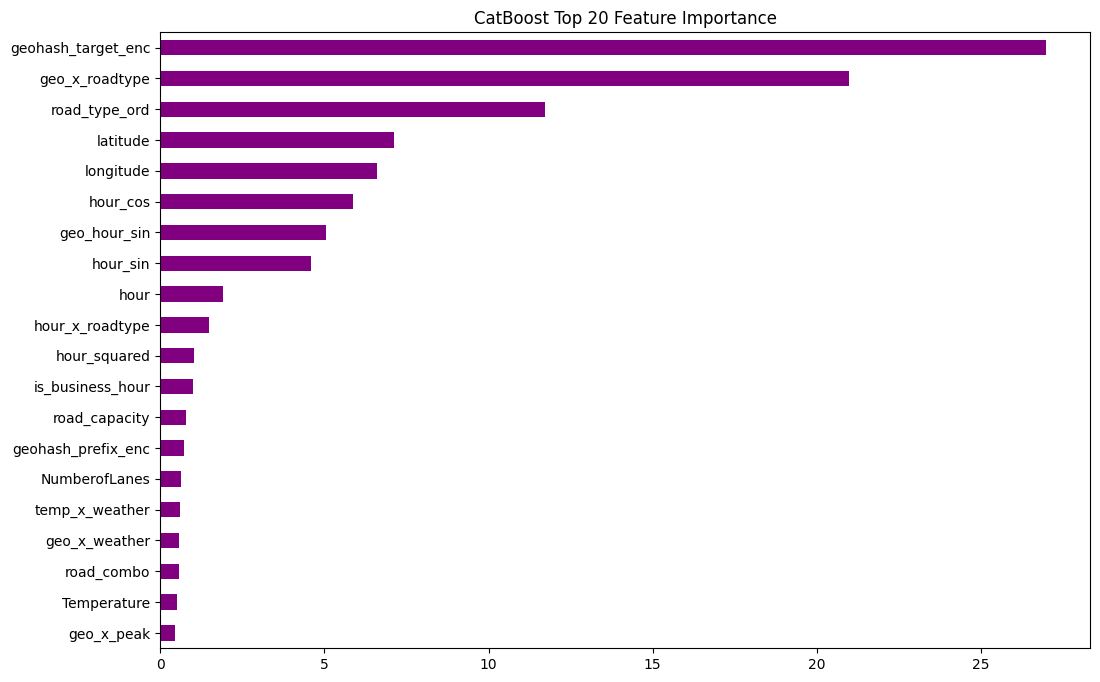

In [7]:
# XGBoost Features
xgb_importances = pd.Series(final_xgb.feature_importances_, index=X.columns).sort_values(ascending=False).head(20)
plt.figure(figsize=(12, 8))
xgb_importances.sort_values().plot(kind='barh', color='teal')
plt.title('XGBoost Top 20 Feature Importance')
plt.savefig(os.path.join(MODEL_DIR, 'xgb_feature_importance.png'))
plt.show()

# LightGBM Features
lgb_importances = pd.Series(final_lgb.feature_importances_, index=X.columns).sort_values(ascending=False).head(20)
plt.figure(figsize=(12, 8))
lgb_importances.sort_values().plot(kind='barh', color='navy')
plt.title('LightGBM Top 20 Feature Importance')
plt.savefig(os.path.join(MODEL_DIR, 'lgb_feature_importance.png'))
plt.show()

# CatBoost Features
cat_importances = pd.Series(final_cat.get_feature_importance(), index=X.columns).sort_values(ascending=False).head(20)
plt.figure(figsize=(12, 8))
cat_importances.sort_values().plot(kind='barh', color='purple')
plt.title('CatBoost Top 20 Feature Importance')
plt.savefig(os.path.join(MODEL_DIR, 'cat_feature_importance.png'))
plt.show()


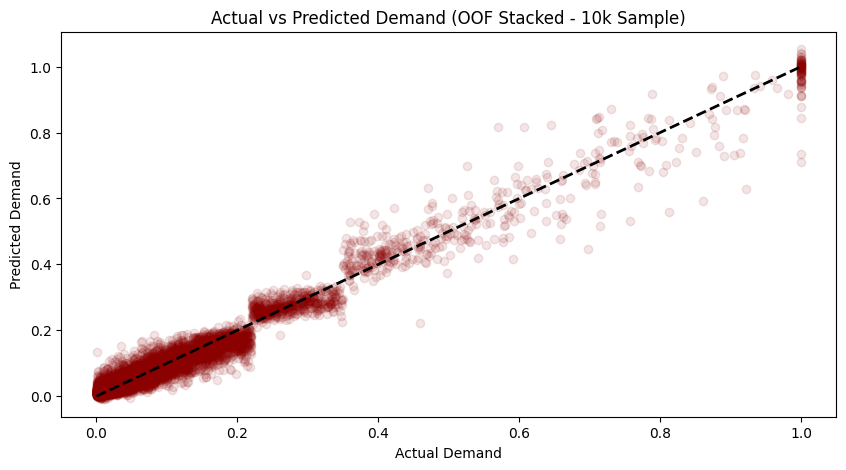

Residuals Mean: -0.0001
Residuals Std: 0.0257
Residuals Min: -0.2462
Residuals Max: 0.2933


In [8]:
sample_idx = np.random.choice(len(y), size=min(10000, len(y)), replace=False)
y_sample = y.iloc[sample_idx].values
pred_sample = oof_stacked_pred[sample_idx]

plt.figure(figsize=(10, 5))
plt.scatter(y_sample, pred_sample, alpha=0.1, color='darkred')
plt.plot([y_sample.min(), y_sample.max()], [y_sample.min(), y_sample.max()], 'k--', lw=2)
plt.title('Actual vs Predicted Demand (OOF Stacked - 10k Sample)')
plt.xlabel('Actual Demand')
plt.ylabel('Predicted Demand')
plt.savefig(os.path.join(MODEL_DIR, 'oof_actual_vs_predicted.png'))
plt.show()

residuals = y_sample - pred_sample
print(f"Residuals Mean: {residuals.mean():.4f}")
print(f"Residuals Std: {residuals.std():.4f}")
print(f"Residuals Min: {residuals.min():.4f}")
print(f"Residuals Max: {residuals.max():.4f}")


In [9]:
# Persist headline metrics so step11_prediction.ipynb can report the actual
# numbers this run produced instead of hardcoding them — the two had already
# drifted out of sync once (this file used to hardcode "Stacked OOF RMSE:
# 0.0263" even after the cross_val_predict fix above changed it to 0.0264).
metrics = {
    'xgb_rmse': float(rmse(y, oof_xgb)),
    'lgb_rmse': float(rmse(y, oof_lgb)),
    'cat_rmse': float(rmse(y, oof_cat)),
    'stacked_rmse': float(stacked_rmse),
    'xgb_r2': float(r2(y, oof_xgb)),
    'lgb_r2': float(r2(y, oof_lgb)),
    'cat_r2': float(r2(y, oof_cat)),
    'stacked_r2': float(stacked_r2),
    'n_features': len(FINAL_FEATURES),
    'xgb_final_trees': xgb_final_n,
    'lgb_final_trees': lgb_final_n,
    'cat_final_trees': cat_final_n,
}

with open(os.path.join(MODEL_DIR, 'metrics.json'), 'w') as f:
    json.dump(metrics, f, indent=2)

print(json.dumps(metrics, indent=2))

{
  "xgb_rmse": 0.030942673546552855,
  "lgb_rmse": 0.027447591557657167,
  "cat_rmse": 0.02739500705323984,
  "stacked_rmse": 0.02639756126708821,
  "xgb_r2": 0.9526434598699599,
  "lgb_r2": 0.9627374321917647,
  "cat_r2": 0.9628800717892183,
  "stacked_r2": 0.9655339187481151,
  "n_features": 26,
  "xgb_final_trees": 1200,
  "lgb_final_trees": 2637,
  "cat_final_trees": 1909
}
